# Counterfactual Explanations Tutorial - Part 1

Welcome to the first part of our counterfactual explanations tutorial! In this notebook, we'll explore the **Wachter et al. (2017)** approach to generating counterfactual explanations.

## What are Counterfactual Explanations?

Counterfactual explanations answer the question: *"What would need to change in the input for the model to produce a different prediction?"*

For example, if a loan application is rejected, a counterfactual explanation might tell us: *"If your income were $5,000 higher and you had 2 fewer credit inquiries, your loan would be approved."*


In [1]:
# Import necessary libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## The Wachter et al. (2017) Formulation

The seminal paper ["Counterfactual Explanations without Opening the Black Box"](https://arxiv.org/pdf/1711.00399) by Wachter et al. introduced a optimization-based approach to generate counterfactual explanations.

### Key Idea

Given:
- An input instance **x** with prediction **f(x)**
- A desired target prediction **y'** (different from f(x))

Find the **closest** instance **x'** such that **f(x') = y'**

### The Optimization Problem

The authors formulate this as a constrained optimization problem:

**minimize** ||x' - x||₂²  
**subject to** f(x') = y'

However, since we're dealing with probabilistic classifiers that output probabilities rather than hard labels, the constraint becomes:

**minimize** ||x' - x||₂²  
**subject to** P(y'|x') ≥ threshold (e.g., 0.5)


## Reformulation as Unconstrained Optimization

To solve this optimization problem using gradient-based methods, we reformulate the constrained problem as an **unconstrained optimization** problem using a loss function:

### The Loss Function

$$L(x') = \lambda_1 \cdot d(x, x') + \lambda_2 \cdot \ell(f(x'), y')$$

Where:
- **d(x, x')**: Distance function (typically L2 distance: ||x' - x||₂²)
- **ℓ(f(x'), y')**: Loss function measuring how far f(x') is from the target y'
- **λ₁, λ₂**: Hyperparameters balancing proximity vs. prediction change

### Distance Component

The distance component encourages the counterfactual to be close to the original:

$$d(x, x') = ||x' - x||_2^2 = \sum_{i=1}^{d} (x'_i - x_i)^2$$

### Prediction Loss Component

For binary classification with target class y', we can use:

$$\ell(f(x'), y') = \max(0, \tau - (f(x') - 0.5) \cdot (2y' - 1))$$

Where:
- **τ**: Margin parameter (e.g., 0.1)
- **f(x')**: Model's probability output for class 1
- **y'**: Target class (0 or 1)

This loss is 0 when the model confidently predicts the target class, and increases as the prediction moves away from the target.

### Alternative: Cross-Entropy Loss

We can also use standard cross-entropy loss:

$$\ell(f(x'), y') = -y' \log(f(x')) - (1-y') \log(1-f(x'))$$

### Gradient-Based Optimization

Since both components are differentiable, we can use gradient descent to minimize L(x'):

$$x'^{(t+1)} = x'^{(t)} - \alpha \nabla_{x'} L(x'^{(t)})$$

Where α is the learning rate.


## Dataset: Two Moons

We'll use the classic "two moons" dataset for our demonstration. This is a 2D binary classification problem where the data forms two interleaving half-circles, making it perfect for visualizing counterfactual explanations.


In [2]:
# Generate the two moons dataset
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

print(f"Training set shape: {X_train_tensor.shape}")
print(f"Test set shape: {X_test_tensor.shape}")
print(f"Class distribution - Class 0: {(y_train == 0).sum()}, Class 1: {(y_train == 1).sum()}")
                                                                                                                                                            

Training set shape: torch.Size([800, 2])
Test set shape: torch.Size([200, 2])
Class distribution - Class 0: 400, Class 1: 400


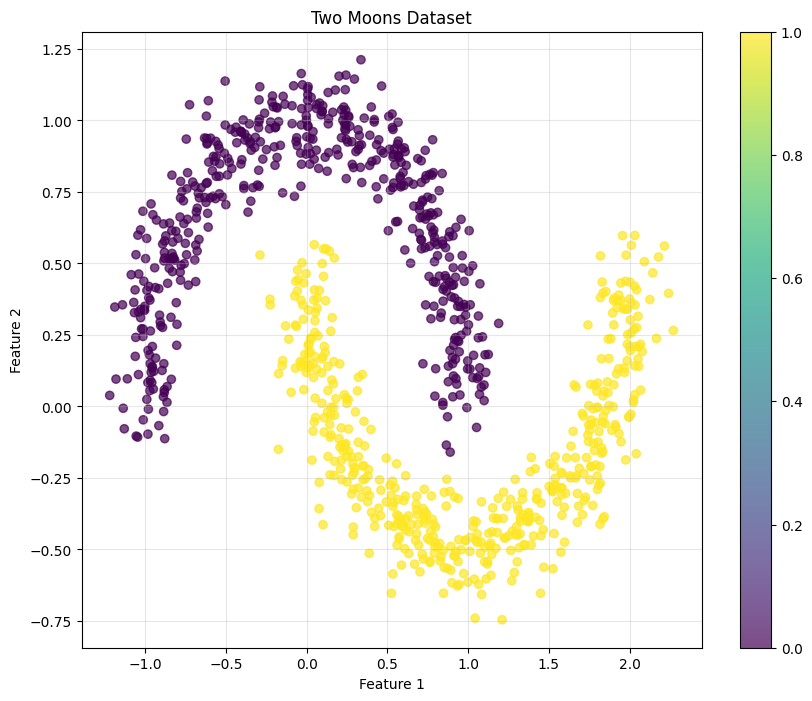

In [3]:
# Visualize the dataset
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.title('Two Moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.show()


## Neural Network Model

We'll create a simple feedforward neural network for binary classification. The model should be complex enough to learn the moons pattern but simple enough for clear counterfactual explanations.


In [ ]:
class LogisticRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        
    def forward(self, x):
        return self.linear(x)
    
    def predict_proba(self, x):
        return torch.softmax(self.forward(x), dim=1)

    def predict(self, X_test):
        if isinstance(X_test, np.ndarray):
            X_test = torch.from_numpy(X_test).float()
        with torch.no_grad():
            probs = self.predict_proba(X_test)
            probs = torch.argmax(probs, dim=1)
            return probs.squeeze().float()

model = LogisticRegression(2, 2)

In [8]:
class MultilayerPerceptron(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, output_dim),
        )
        
    def forward(self, x):
        return self.layers(x)
    
    def predict_proba(self, x):
        return torch.softmax(self.forward(x), dim=1)

    def predict(self, X_test):
        if isinstance(X_test, np.ndarray):
            X_test = torch.from_numpy(X_test).float()
        with torch.no_grad():
            probs = self.predict_proba(X_test)
            probs = torch.argmax(probs, dim=1)
            return probs.squeeze().float()

model = MultilayerPerceptron(2, 2)

## Model Training


In [9]:
from src.training import train_model

train_model(model, X_train_tensor, y_train_tensor)

Epoch [20/100], Loss: 0.0020, Accuracy: 1.0000
Epoch [40/100], Loss: 0.0000, Accuracy: 1.0000
Epoch [60/100], Loss: 0.0000, Accuracy: 1.0000
Epoch [80/100], Loss: 0.0000, Accuracy: 1.0000
Epoch [100/100], Loss: 0.0000, Accuracy: 1.0000
Training completed!


<Axes: >

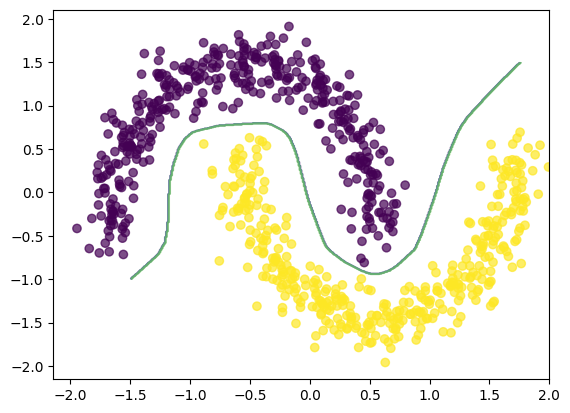

In [11]:
import matplotlib.pyplot as plt
from src.visualization.plot_utils import plot_classifier_decision_region
fig, ax = plt.subplots(1, 1)
ax.scatter(X_train_tensor.numpy()[:, 0], X_train_tensor.numpy()[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plot_classifier_decision_region(ax, model)

In [ ]:
from counterfactuals import CounterfactualGenerator

counterfactual_generator = CounterfactualGenerator(model)
counterfactual_generator.generate(X_test_tensor[0], y_test_tensor[0])


---

# 🚀 **YOUR TURN: Implement Counterfactual Generation**

Now it's time for you to implement the counterfactual generation algorithm based on the Wachter et al. formulation we discussed above!

## Task Overview

Your goal is to implement a `CounterfactualGenerator` class that:

1. **Takes an input instance** and finds the closest counterfactual explanation
2. **Uses gradient-based optimization** to minimize the loss function: `L(x') = λ₁ * d(x, x') + λ₂ * ℓ(f(x'), y')`
3. **Returns the counterfactual instance** that changes the model's prediction

## Implementation Guidelines

### Class Structure
```python
class CounterfactualGenerator:
    def __init__(self, model, lambda1=1.0, lambda2=1.0, lr=0.01, max_iterations=1000):
        # Initialize your counterfactual generator
        pass
    
    def generate(self, x_orig, target_class, tolerance=0.1):
        # Generate counterfactual explanation for x_orig
        # Returns: counterfactual instance, success flag, iterations used
        pass
```

### Key Components to Implement

1. **Distance Function**: Implement L2 distance `d(x, x')`
2. **Prediction Loss**: Choose between margin loss or cross-entropy loss
3. **Gradient Optimization**: Use PyTorch's autograd for gradient computation
4. **Stopping Criteria**: Stop when target prediction is achieved or max iterations reached

### Hints

- Initialize `x'` as a copy of the original input `x`
- Make `x'` a PyTorch tensor with `requires_grad=True`
- Use `torch.optim.Adam` or `torch.optim.SGD` for optimization
- Clamp or constrain `x'` if needed (e.g., for valid feature ranges)
- Track the loss components separately for debugging

## Your Implementation Space

👇 **Write your code in the cells below** 👇


In [ ]:
# TODO: Implement your CounterfactualGenerator class here

class CounterfactualGenerator:
    def __init__(self, model, lambda1=1.0, lambda2=1.0, lr=0.01, max_iterations=1000):
        """
        Initialize the counterfactual generator
        
        Args:
            model: Trained PyTorch model
            lambda1: Weight for distance loss
            lambda2: Weight for prediction loss  
            lr: Learning rate for optimization
            max_iterations: Maximum number of optimization steps
        """
        # YOUR CODE HERE
        pass
    
    def distance_loss(self, x_orig, x_cf):
        """
        Compute L2 distance between original and counterfactual
        
        Args:
            x_orig: Original input
            x_cf: Counterfactual input
            
        Returns:
            L2 distance loss
        """
        # YOUR CODE HERE
        pass
    
    def prediction_loss(self, x_cf, target_class):
        """
        Compute prediction loss (how far is the prediction from target)
        
        Args:
            x_cf: Counterfactual input
            target_class: Desired target class
            
        Returns:
            Prediction loss
        """
        # YOUR CODE HERE
        pass
    
    def generate(self, x_orig, target_class, tolerance=0.1):
        """
        Generate counterfactual explanation
        
        Args:
            x_orig: Original input instance
            target_class: Desired target class (0 or 1)
            tolerance: Tolerance for stopping criterion
            
        Returns:
            counterfactual: Generated counterfactual instance
            success: Whether counterfactual was successfully found
            iterations: Number of optimization iterations used
        """
        # YOUR CODE HERE
        pass

# TODO: Test your implementation with some examples from the test set
